# Crazyflie active-sensing observability example

This notebook mirrors `references/pybounds_examples/fly_wind_example.ipynb`, but uses **this
project's own crazyflie-like drone model** (`model/drone_simulator.py`) instead of the
insect/wind model, and runs the observability analysis on a **real generated trajectory loaded
from `simulated_trajectories/`** (produced by `utils/trajectory_generator.py`), rather than a
trajectory designed and MPC-simulated inside this notebook.

The question we're asking is the one from `elaborate_plan.md` Phase 1: with only an optical-flow
sensor (like the Flow deck v2) and an accelerometer (the onboard IMU) -- i.e. **no direct height
sensor** -- when does altitude `z` actually become observable? The reference paper
(`references/summaries/bens_epic_paper.md`) found that altitude is only observable during
**horizontal acceleration/deceleration**, not during hover or turning, because optic flow only
measures the ratio `velocity / z`. We replicate that same empirical-observability analysis here,
using our own model's dynamics and our own generated flight data, instead of assuming the paper's
result transfers unchanged.

# Install pybounds and requirements

This should allow the notebook to run directly in google colab.

In [1]:
try:
  import casadi
except:
  !pip install casadi
  import casadi

try:
  import do_mpc
except:
  !pip install do_mpc
  import do_mpc

try:
  import pybounds
except:
  !pip install pybounds
  import pybounds

/home/cherry/Documents/ai_kalman_on_crazyflie/.venv/lib/python3.12/site-packages/do_mpc/sysid/__init__.py:15: UserWarning: The ONNX feature is not available. Please install the full version of do-mpc to access this feature.
  warnings.warn('The ONNX feature is not available. Please install the full version of do-mpc to access this feature.')
/home/cherry/Documents/ai_kalman_on_crazyflie/.venv/lib/python3.12/site-packages/do_mpc/opcua/__init__.py:14: UserWarning: The opcua feature is not available. Please install the full version of do-mpc to access this feature.
  warnings.warn('The opcua feature is not available. Please install the full version of do-mpc to access this feature.')
/home/cherry/Documents/ai_kalman_on_crazyflie/.venv/lib/python3.12/site-packages/do_mpc/approximateMPC/__init__.py:13: UserWarning: The approximateMPC feature requires PyTorch, which is not installed by default. Please install the full version of do-mpc to use this feature: pip install do_mpc[full]
  warnings

# Import packages

In [ ]:
import sys
import os
import json
from pathlib import Path
sys.path.append(os.path.abspath('.'))

import time
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

from pybounds import SlidingEmpiricalObservabilityMatrix, FisherObservability, SlidingFisherObservability, ObservabilityMatrixImage, colorline

# This project's crazyflie-like drone model
from model.drone_simulator import DroneModel, DroneSimulator

### Compatibility shim (newer numpy)

Some numpy releases no longer allow implicit conversion of a size-1, non-0-d array to a Python
scalar via `int()`/`np.round()`. `do_mpc` passes its internal time (`self._t0`, shape `(1,)`) into
`pybounds.Simulator.simulator_tvp_function`/`mpc_tvp_function`, which do exactly that conversion,
so on such numpy versions `simulator.simulate(mpc=True)` raises
`TypeError: only 0-dimensional arrays can be converted to Python scalars`.

This cell patches around it at runtime (no installs, no version changes) by coercing `t` to a
plain float before handing it to the original methods. It must run before `DroneSimulator(...)`
is instantiated below, since `Simulator.__init__` captures these methods as callbacks.

In [3]:
from pybounds import Simulator as _PyBoundsSimulator


def _scalar_time(t):
    """Coerce a possibly-array-shaped time value to a plain Python float."""
    return float(np.asarray(t).reshape(-1)[0])


_orig_simulator_tvp_function = _PyBoundsSimulator.simulator_tvp_function
_orig_mpc_tvp_function = _PyBoundsSimulator.mpc_tvp_function


def _patched_simulator_tvp_function(self, t):
    return _orig_simulator_tvp_function(self, _scalar_time(t))


def _patched_mpc_tvp_function(self, t):
    return _orig_mpc_tvp_function(self, _scalar_time(t))


_PyBoundsSimulator.simulator_tvp_function = _patched_simulator_tvp_function
_PyBoundsSimulator.mpc_tvp_function = _patched_mpc_tvp_function

# Define system dynamics and measurements

This example uses `model/drone_simulator.py`'s `DroneModel`/`DroneSimulator`, a planar-drone model
adapted for a hovering, GPS-denied quadcopter (i.e. a Crazyflie) rather than a free-flying insect.

The system dynamics are described by twelve states (in the body-level, moving-frame
configuration we use below):
* `x`, `y` - position in the inertial frame [m]
* `z` - altitude [m]
* `v_x`, `v_y` - body-level forward/lateral velocity [m/s]
* `v_z` - vertical velocity [m/s]
* `psi` - yaw heading [rad]
* `w`, `zeta` - ambient wind speed/direction (kept at 0 here -- there is no meaningful ambient
  wind for an indoor Crazyflie flight, but the state exists for model generality / reuse of the
  same model class outdoors)
* `k_x`, `k_y`, `k_psi` - motor/velocity-control calibration coefficients

with inputs `u_x`, `u_y` (body-level accelerations), `u_psi` (yaw rate), `u_z` (vertical
acceleration), `u_w`, `u_zeta` (wind rate of change).

The measurement function returns every state and input (useful for observability experiments --
you can ask "what if I had a direct sensor for this state"), plus a set of derived measurements
that map directly onto real Crazyflie hardware:
* `r_x = v_x / z`, `r_y = v_y / z` -- **optical flow** in body x/y, exactly what the Flow deck v2
  (PMW3901) provides. Note this is the same velocity/height ambiguity the reference paper's
  altitude sub-problem is built around.
* `v_x_dot`, `v_y_dot` -- body-level accelerations (including rotational-coupling terms), the
  closest analog to the onboard **accelerometer**.
* `g`, `beta` -- ground speed magnitude/angle.
* `a_x`, `a_y`, `a`, `gamma` -- apparent airflow (not physically available on a Crazyflie -- no
  airspeed sensor -- included only because the model is shared with the outdoor flying-agent case).
* `w_x`, `w_y` -- wind components (likewise not relevant indoors).

For the "impaired sensor" scenario (no direct height sensor, matching the project's grand-prize
goal), the only measurements we assume are available are `r_x`, `r_y` (flow deck) and `v_x_dot`,
`v_y_dot` (IMU accelerometer). We compare that against a "full sensor" baseline that also includes
`z` directly (as if a ToF/height sensor were present), which should trivially make `z` observable
everywhere.

# Load a trajectory from `simulated_trajectories/`

Instead of designing a setpoint and running MPC in this notebook, we load a trajectory that
`utils/trajectory_generator.py` already generated (it ran the same `DroneSimulator` + MPC
pipeline once, for one of several motifs -- sinusoidal, straight, accel/decel pulse, turn, circle,
casting, or random -- and saved the result to a compressed CSV).

Change `TRAJECTORY_FILE` below to inspect a different trajectory (see
`visualize_trajectories.ipynb` for a gallery of what's available). By default we try to pick an
`accel_decel` example, since that's the motif the reference paper's finding is specifically about;
if none exist yet in `simulated_trajectories/`, we fall back to whatever motif is available and
say so clearly -- the analysis below still runs, it just may not show the accel/decel effect if
the loaded trajectory doesn't contain one.

In [ ]:
SIMULATED_TRAJECTORIES_DIR = Path('simulated_trajectories')
manifest_path = SIMULATED_TRAJECTORIES_DIR / 'manifest.csv'

if not manifest_path.exists():
    raise FileNotFoundError(
        f'{manifest_path} not found -- run `python3 utils/trajectory_generator.py` first '
        f'to generate at least one trajectory.')

manifest = pd.read_csv(manifest_path)
manifest['motif'] = manifest['params_json'].apply(lambda s: json.loads(s)['motif'])
print(f'{len(manifest)} trajectories available: {manifest["motif"].value_counts().to_dict()}')

# Pick a trajectory -- prefer an accel/decel example (the motif this notebook is about), else
# fall back to whatever's available. Change this line to inspect a specific file instead.
if 'accel_decel' in manifest['motif'].values:
    TRAJECTORY_FILE = manifest[manifest['motif'] == 'accel_decel'].iloc[0]['filename']
else:
    TRAJECTORY_FILE = manifest.iloc[0]['filename']
    print(f'no accel_decel trajectory found yet -- falling back to "{TRAJECTORY_FILE}" '
          f'(motif={manifest.iloc[0]["motif"]}). Generate more trajectories for the full picture.')

trajectory_df = pd.read_csv(SIMULATED_TRAJECTORIES_DIR / TRAJECTORY_FILE)
trajectory_metadata = json.loads(
    manifest.loc[manifest['filename'] == TRAJECTORY_FILE, 'params_json'].iloc[0])

dt = float(np.median(np.diff(trajectory_df['time'].values)))  # infer sample rate from the data

print(f'loaded: {TRAJECTORY_FILE}')
print(f'metadata: {trajectory_metadata}')
print(f'dt={dt:.4f}s  duration={trajectory_df["time"].iloc[-1]:.2f}s  rows={len(trajectory_df)}')

# Create simulator object

In [ ]:
# dt comes from the loaded trajectory (inferred above), not hardcoded, so the model matches
# whatever sample rate the trajectory was actually generated at.
simulator = DroneSimulator(frame='body_level', moving_frame='on', dt=dt, mpc_horizon=10)

print('states:', simulator.state_names)
print('inputs:', simulator.input_names)
print('measurements:', simulator.measurement_names)

# Build t_sim / x_sim / u_sim from the loaded trajectory

`SlidingEmpiricalObservabilityMatrix` expects `t_sim` (time array) plus `x_sim`/`u_sim` dicts
keyed by the simulator's own state/input names (e.g. `'z'`, `'v_x'`), in the same order as
`simulator.state_names`/`input_names` -- exactly what `simulator.simulate(..., return_full_output=True)`
used to return directly. Since we loaded the data from a CSV instead (where
`trajectory_generator.py` prefixed columns as `state_*`/`input_*`/`meas_*` to avoid name
collisions on disk), we rebuild that same dict format here by stripping the prefixes back off, in
the correct order.

We also repopulate the simulator's own `.x`/`.u`/`.time` so the existing `simulator.plot('x')`/
`simulator.plot('u')` calls below keep working unchanged, even though we never called
`simulator.simulate()` this time.

Since each generated trajectory is a single motif (not the old hand-scripted multi-segment demo),
we replace the previous hardcoded `motif_segments` shading with a **data-driven** one: we shade
whichever time windows have above-median horizontal acceleration magnitude
(`sqrt(v_x_dot^2 + v_y_dot^2)`), so the "does z become observable when the drone accelerates"
story still shows up visually, whatever motif was actually loaded.

In [ ]:
t_sim = trajectory_df['time'].values

x_sim = {name: trajectory_df[f'state_{name}'].values for name in simulator.state_names}
u_sim = {name: trajectory_df[f'input_{name}'].values for name in simulator.input_names}

# Repopulate the simulator's own state so simulator.plot('x')/simulator.plot('u') below keep
# working unchanged, even though we never called simulator.simulate() this time.
for name, values in x_sim.items():
    simulator.x[name] = values
for name, values in u_sim.items():
    simulator.u[name] = values
simulator.time = t_sim

# Data-driven stand-in for the old hand-scripted motif_segments: shade whichever windows have
# above-the-75th-percentile horizontal acceleration magnitude, whatever motif was actually loaded.
accel_magnitude = np.sqrt(trajectory_df['meas_v_x_dot'].values ** 2 +
                          trajectory_df['meas_v_y_dot'].values ** 2)
high_accel_mask = accel_magnitude > np.percentile(accel_magnitude, 75)


def mask_to_segments(t, mask):
    """Convert a boolean mask over `t` into a list of (t_start, t_end, 'high accel') runs,
    same (t0, t1, label) shape the old hardcoded motif_segments used, for downstream shading."""
    segments = []
    in_run = False
    for i, flag in enumerate(mask):
        if flag and not in_run:
            start_i = i
            in_run = True
        elif not flag and in_run:
            segments.append((t[start_i], t[i - 1], 'high accel'))
            in_run = False
    if in_run:
        segments.append((t[start_i], t[-1], 'high accel'))
    return segments


motif_segments = mask_to_segments(t_sim, high_accel_mask)
motif_name = trajectory_metadata['motif']
print(f'motif: {motif_name}  |  {len(motif_segments)} high-acceleration window(s) shaded below')

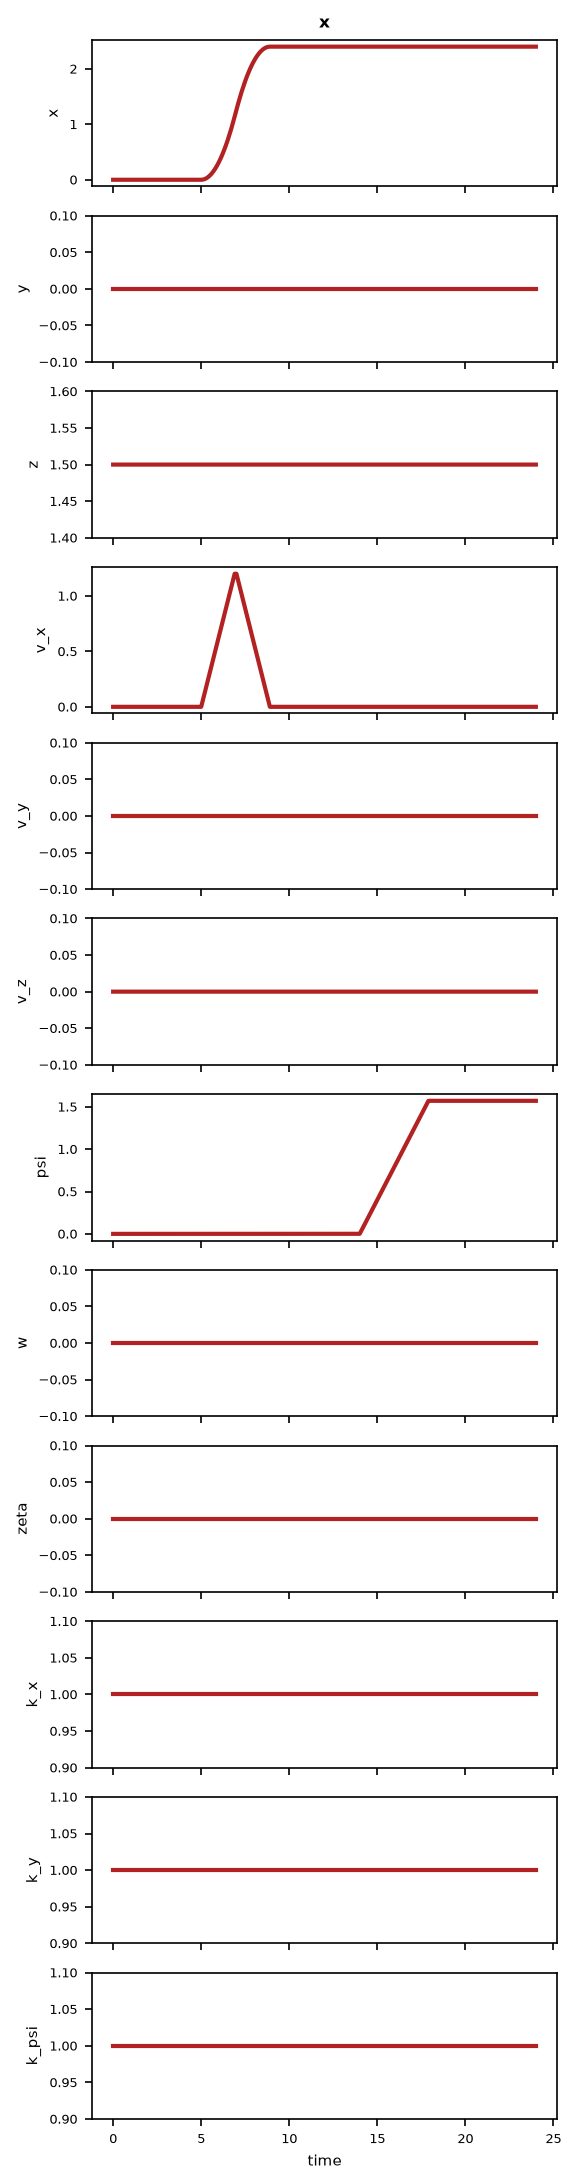

In [7]:
# Plot state tracking
simulator.plot('x')

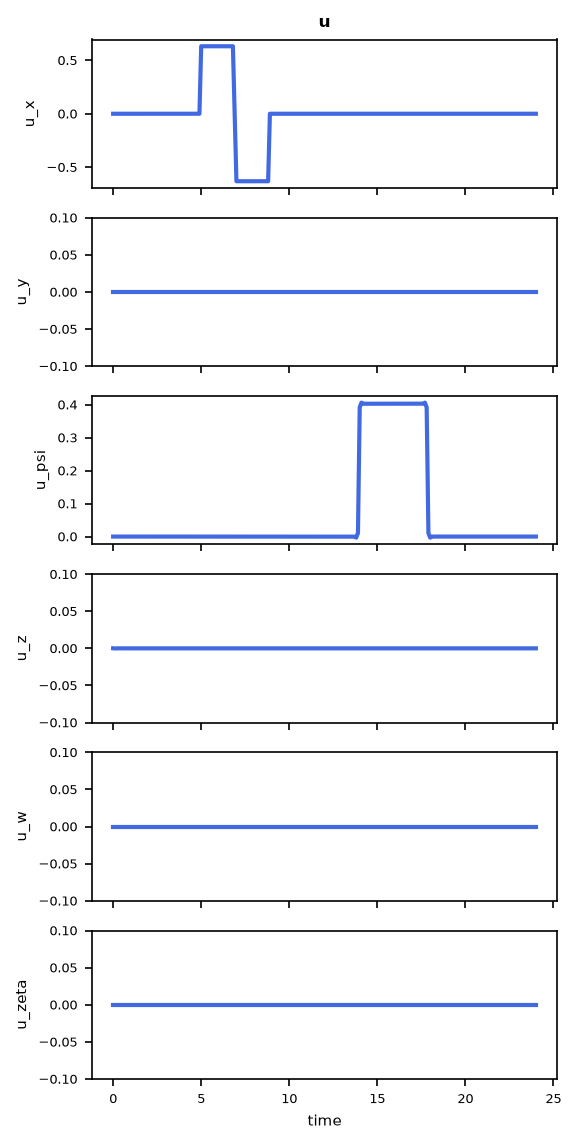

In [8]:
# Plot inputs
simulator.plot('u')

In [ ]:
# Plot the x-y trajectory (colored by time), plus v_x and z over time to visually confirm the
# loaded motif, with high-horizontal-acceleration windows shaded.
fig, ax = plt.subplots(1, 3, figsize=(12, 3), dpi=150)
fig.suptitle(f'motif: {motif_name}  ({TRAJECTORY_FILE})', fontsize=9)

ax[0].plot(x_sim['x'], x_sim['y'])
ax[0].set_xlabel('x pos [m]')
ax[0].set_ylabel('y pos [m]')
ax[0].set_title('trajectory (x-y)')
ax[0].set_aspect('equal')

ax[1].plot(t_sim, x_sim['v_x'], label='v_x')
ax[1].plot(t_sim, x_sim['psi'], label='psi')
ax[1].set_xlabel('time [s]')
ax[1].set_title('v_x & psi')
ax[1].legend(fontsize=7)

ax[2].plot(t_sim, x_sim['z'])
ax[2].set_xlabel('time [s]')
ax[2].set_title('z (altitude, held at setpoint)')

for a in ax[1:]:
    for (t0, t1, label) in motif_segments:
        if label == 'high accel':
            a.axvspan(t0, t1, color='tab:orange', alpha=0.15)

fig.tight_layout()
plt.show()

# Observability

## Construct the observability matrix in sliding windows

Heads up on runtime: this step perturbs every state variable and re-simulates twice per window
(mpc=False, so no MPC/QP solve -- much faster than a fresh MPC run, but still real simulation
work). The original synthetic 24s/dt=0.1 demo trajectory (241 steps) took ~80s here; a real
generated trajectory sampled at 100 Hz (dt=0.01, ~1100 steps for an 11s flight) has ~4x more
windows to compute, so expect this cell to take longer -- it's still much faster than re-running
MPC would be.

In [ ]:
# Window size in steps, computed from the loaded dt so it always corresponds to ~1.0s of
# physical time regardless of the trajectory's sample rate. Set to None to use the whole
# time-series as a single window.
w = int(round(1.0 / dt))
print(f'window size: {w} steps ({w * dt:.2f}s)')

In [11]:
# Construct O in sliding windows. This is the computationally heavy step: it perturbs every
# state variable and re-simulates the measurements, for every window along the trajectory.
st = time.time()
SEOM = SlidingEmpiricalObservabilityMatrix(simulator, t_sim, x_sim, u_sim, w=w, eps=1e-4)
et = time.time()
print('elapsed time:', et - st)

O_sliding = SEOM.get_observability_matrix()
print(len(O_sliding), 'windows')

elapsed time: 78.89266610145569
232 windows


## Compare an "impaired" sensor set against a "full" sensor set

This is the core experiment from `elaborate_plan.md` Phase 1: does `z` become observable from
optical flow + accelerometer alone, and if so, only during specific motifs?

* **impaired** -- flow deck (`r_x`, `r_y`) + accelerometer (`v_x_dot`, `v_y_dot`) only. This is
  the "no direct vertical height measurement" scenario from the project's grand-prize goal.
* **full** -- the impaired set plus a direct height measurement `z` (as if a ToF/z-ranger sensor
  were present), used only as a sanity-check baseline: `z` should be trivially observable
  everywhere in this case.

In [12]:
# Set each sensor's noise standard deviation, then convert to variance for use as R
measurement_noise_stds = {
    'r_x': 0.05,       # optical flow, x [1/s]
    'r_y': 0.05,       # optical flow, y [1/s]
    'v_x_dot': 0.2,    # accelerometer, x [m/s^2]
    'v_y_dot': 0.2,    # accelerometer, y [m/s^2]
    'z': 0.02,         # direct height/ToF measurement [m] ("full" sensor set only)
}
measurement_noise_vars = {key: val ** 2 for key, val in measurement_noise_stds.items()}

impaired_sensors = ['r_x', 'r_y', 'v_x_dot', 'v_y_dot']
full_sensors = impaired_sensors + ['z']

In [13]:
# Choose states of interest
o_states = ['z', 'v_x', 'v_y', 'psi']

# Choose time-steps to use from O (cannot be larger than the window size w defined above)
window_size = w
o_time_steps = np.arange(0, window_size, step=1)

sensor_sets = {'impaired (flow + accel only)': impaired_sensors,
               'full (flow + accel + height)': full_sensors}

min_error_variance = {}
for label, sensors in sensor_sets.items():
    o_measurement_noise_vars = {key: measurement_noise_vars[key] for key in sensors}

    SFO = SlidingFisherObservability(SEOM.O_df_sliding, time=SEOM.t_sim, lam=1e-8,
                                     R=o_measurement_noise_vars,
                                     states=o_states, sensors=sensors, time_steps=o_time_steps, w=None)

    EV = SFO.get_minimum_error_variance()
    try:
        EV = EV.bfill().ffill()
    except AttributeError:
        EV = EV.fillna(method='bfill').fillna(method='ffill')

    min_error_variance[label] = EV

min_error_variance['full (flow + accel + height)'].head()

,time,time_initial,z,v_x,v_y,psi
0,0.0,0.0,0.00004,0.000563,0.000563,100000000.0
1,0.1,0.0,0.00004,0.000563,0.000563,100000000.0
2,0.2,0.0,0.00004,0.000563,0.000563,100000000.0
3,0.3,0.0,0.00004,0.000563,0.000563,100000000.0
4,0.4,0.0,0.00004,0.000563,0.000563,100000000.0


## Plot z's minimum error variance over time, for each sensor set

If the paper's finding transfers to our model, we should see the impaired sensor set's `z` error
variance drop sharply (better observability) only during the acceleration/deceleration pulse
(shaded orange), stay flat/high during hover, and *not* meaningfully improve during the heading
turn (shaded green) -- while the full sensor set's `z` error variance should stay low throughout.

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4), dpi=150)
fig.suptitle(f'motif: {motif_name}', fontsize=9)

for (t0, t1, label) in motif_segments:
    if label == 'high accel':
        ax.axvspan(t0, t1, color='tab:orange', alpha=0.15, label='high horizontal accel')

colors = {'impaired (flow + accel only)': 'firebrick', 'full (flow + accel + height)': 'gray'}
for label, EV in min_error_variance.items():
    ax.plot(EV['time'], EV['z'], label=label, color=colors.get(label), linewidth=2.0)

ax.set_yscale('log')
ax.set_xlabel('time (s)')
ax.set_ylabel('min. error variance: z')

# De-duplicate the axvspan legend entries
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), fontsize=7, loc='upper right')

fig.tight_layout()
plt.show()

## Per-state error-variance grid, impaired sensor set only

Same style as `fly_wind_example.ipynb`'s final plot, but only for the impaired (flow + accel)
sensor set, so we can also see how `v_x`, `v_y`, and `psi` observability behave across the same
motifs.

In [ ]:
EV_impaired = min_error_variance['impaired (flow + accel only)']

cmap = 'inferno_r'
n_state = len(o_states)

fig, ax = plt.subplots(n_state, 1, figsize=(6, n_state * 2), dpi=150, sharex=True)
ax = np.atleast_1d(ax)
fig.suptitle(f'motif: {motif_name}', fontsize=9)

for n, state_name in enumerate(o_states):
    ev = EV_impaired[state_name].values
    min_ev = np.nanmin(ev[ev > 0]) if np.any(ev > 0) else 1e-6
    max_ev = np.nanmax(ev)
    log_tick_low = int(np.floor(np.log10(max(min_ev, 1e-12))))
    log_tick_high = int(np.ceil(np.log10(max(max_ev, min_ev * 10))))
    cnorm = mpl.colors.LogNorm(10 ** log_tick_low, 10 ** log_tick_high)

    colorline(EV_impaired['time'].values, x_sim[state_name][:len(EV_impaired)], ev,
              ax=ax[n], cmap=cmap, norm=cnorm)

    for (t0, t1, label) in motif_segments:
        if label == 'high accel':
            ax[n].axvspan(t0, t1, color='tab:orange', alpha=0.1)

    ax[n].set_ylabel(state_name, fontsize=8)

    cax = ax[n].inset_axes([1.02, 0.0, 0.02, 1.0])
    cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=cnorm, cmap=cmap), cax=cax)
    cbar.set_label('min. EV', rotation=270, fontsize=7, labelpad=8)
    cbar.ax.tick_params(labelsize=6)

ax[-1].set_xlabel('time (s)')
fig.tight_layout()
plt.show()

# Conclusion

With only optical flow (`r_x`, `r_y`) and accelerometer (`v_x_dot`, `v_y_dot`) measurements -- no
direct height sensor -- altitude `z`'s minimum error variance should drop specifically during
high-horizontal-acceleration windows (shaded orange above), and stay flat elsewhere. That would
confirm, on this project's own crazyflie model *and real generated flight data* (not just the
reference paper's model, and not just a hand-scripted demo trajectory), the counter-intuitive
design implication from `elaborate_plan.md`: to make altitude observable without a height sensor,
the Crazyflie should fly brief **horizontal acceleration/deceleration pulses**, not vertical
bobbing or turning.

The `motif` printed by the "load a trajectory" cell near the top tells you which motif was
actually analyzed above -- if it's not `accel_decel`, that's because no `accel_decel` trajectory
existed yet in `simulated_trajectories/` when this ran; regenerate more trajectories
(`python3 utils/trajectory_generator.py`) and re-run this notebook (or just change
`TRAJECTORY_FILE`) to compare motifs directly.

This notebook is the Phase 1 ("model & simulation replication") deliverable from
`elaborate_plan.md`, now wired directly to the Phase 2 data pipeline (`utils/trajectory_generator.py`
-> `simulated_trajectories/` -> this notebook -> eventually `train.py`'s ANN estimator). The
sensor-noise assumptions below (`measurement_noise_stds`) should eventually be replaced with
values measured from the real Flow deck v2 and onboard IMU.

# Exercises

1. Change `TRAJECTORY_FILE` to a different motif (once more have been generated) -- does `turn`
   or `circle` show the same `z`-observability improvement during their high-accel windows, or
   does only `accel_decel` show it cleanly?
2. Try the `full_sensors` set but with a much larger `z` noise standard deviation (a noisier
   height sensor) -- at what noise level does the impaired sensor set start to out-perform it
   during high-acceleration windows?
3. Lower the `high_accel_mask` percentile threshold (e.g. from 75th to 50th) -- does the
   `z`-observability improvement track the shaded regions more or less cleanly?